This code is to visualize yolo and mask annotations for a beemachine partwhole dataset

In [1]:
import os
import yaml
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as mPolygon
from PIL import Image

In [2]:
# Paths
DATA_DIR = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/"
yaml_path = os.path.join(DATA_DIR, 'data.yaml') # "/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/data.yaml"
images_dir = os.path.join(DATA_DIR, 'train', 'aug_images') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/images"
yolo_labels_dir = os.path.join(DATA_DIR, 'train', 'aug_labels') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/LABELS"
images = os.listdir(images_dir) # Get the list of images
images.sort() # Sorting images based on the name

Get color spectrum for consistant part labeling

In [3]:
def get_spectrum_colors(class_ids, cmap_name="viridis"):
    class_ids = sorted(class_ids)
    cmap = plt.get_cmap(cmap_name)
    n = len(class_ids)

    return {
        cid: cmap(i / max(n - 1, 1))[:3]  # drop alpha
        for i, cid in enumerate(class_ids)
    }

# Load class names from YAML
with open(yaml_path, 'r') as file:
    # Use safe_load for security, as it prevents arbitrary code execution
    config = yaml.safe_load(file)
print(config)
LABELS = config['names']
if 'background' not in LABELS:
    LABELS.insert(0, 'background')
print(LABELS)
CLASS_COLORS = get_spectrum_colors(range(len(LABELS)), "turbo")

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 3, 'names': ['abdomen', 'head', 'thorax'], 'roboflow': {'workspace': 'test-f3zdy', 'project': 'beemachine-aqnj1', 'version': 10, 'license': 'MIT', 'url': 'https://universe.roboflow.com/test-f3zdy/beemachine-aqnj1/dataset/10'}}
['background', 'abdomen', 'head', 'thorax']


In [4]:
# Function to plot yolo annotation
def plot_yolo_annotation(image_path, label_path, ax):
    global LABELS, CLASS_COLORS
    image = Image.open(image_path)
    w, h = image.size

    # Read YOLO segmentation annotations
    annotations = []
    with open(label_path, "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            cls_id = int(parts[0])
            coords = list(map(float, parts[1:]))
            # Convert normalized coords → pixel coords
            poly = [(coords[i] * w, coords[i+1] * h) for i in range(0, len(coords), 2)]
            annotations.append((cls_id, poly))

    # Plot
    ax.imshow(image)
    ax.set_title("Fixed yolo partwhole annotations")
    for cls_id, poly in annotations:
        polygon = mPolygon(poly, closed=True, edgecolor=CLASS_COLORS[cls_id], fill=False, linewidth=2)
        ax.add_patch(polygon)
        # Label
        x, y = poly[0]
        label = f"{cls_id, LABELS[cls_id+1]}"
        ax.text(x, y, label, 
                color=CLASS_COLORS[cls_id], fontsize=10, bbox=dict(facecolor='white', alpha=0.5))

# Function to plot mask annotation
def plot_mask_annotation(image_path, mask_path, ax):
    global LABELS, CLASS_COLORS
    np.random.seed(30) # Same color everytime
    image = Image.open(image_path)
    mask = Image.open(mask_path).convert("L")  # class-index mask
    mask_np = np.array(mask)
    ax.set_title("Fixed mask annotations")
    ax.imshow(image)
    class_ids = np.unique(mask_np)
    # class_ids = class_ids[class_ids != 0]    
    color_mask = np.zeros((*mask_np.shape, 3), dtype=float)
    for cid in class_ids:
        color_mask[mask_np == cid] = CLASS_COLORS[cid]
    ax.imshow(color_mask, alpha=0.5)    
    for cid in class_ids:
        ax.plot([], [], color=CLASS_COLORS[cid], label=f"{cid}: {LABELS[cid]}")
    ax.legend()

Plot YOLO annotations

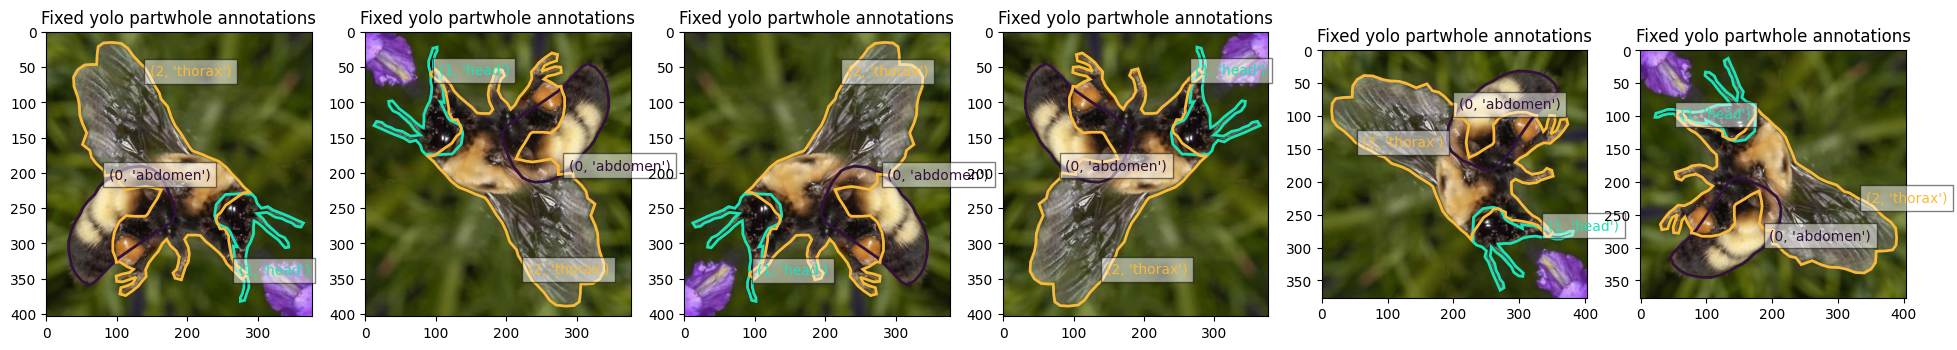

In [5]:
fig, axes = plt.subplots(1, 6, figsize=(24,4))
for i in range(6):
    image_file = images[204+i]
    label_file = os.path.splitext(image_file)[0] + ".txt"
    image_path = os.path.join(images_dir, image_file)
    label_path = os.path.join(yolo_labels_dir, label_file)
    plot_yolo_annotation(image_path, label_path, axes[i])

Plot mask annotations

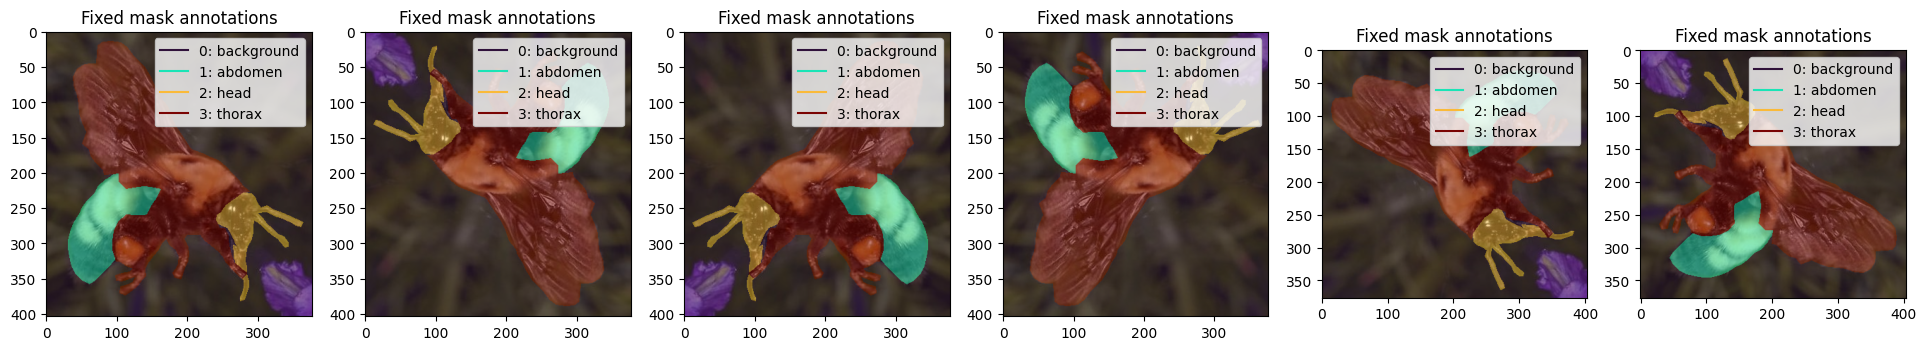

In [6]:
fig, axes = plt.subplots(1, 6, figsize=(24,4))
for i in range(6):
    image_file = images[204+i]
    image_path = os.path.join(images_dir, image_file)
    mask_path = os.path.join(DATA_DIR, 'train', 'aug_masks', image_file[:-4] + "_m.png")
    plot_mask_annotation(image_path, mask_path, axes[i])

Using dataset

In [7]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

# Hyperparameters
DEVICE_ID = 7
BATCH_SIZE = 128
IMAGE_SIZE = 320

In [8]:
class PartWholeDataset(Dataset):
    def __init__(self, root, image_size=320):
        self.images_dir = os.path.join(root, "images")
        self.masks_dir = os.path.join(root, "masks")
        self.image_paths = sorted([os.path.join(self.images_dir, f) for f in os.listdir(self.images_dir)])
        self.image_size = image_size

        # transform for image
        self.img_transform = transforms.Compose([
            transforms.Resize((image_size, image_size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            # transforms.Normalize(mean=[0.5016, 0.4647, 0.3782], std=[0.2738, 0.2654, 0.2885]) # Computed using the find_mean_and_sd_of_partwhole_dataset script
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        base = os.path.splitext(os.path.basename(img_path))[0]
        mask_path = os.path.join(self.masks_dir, base + "_m.png")

        img = Image.open(img_path).convert("RGB")
        img = self.img_transform(img)
        mask = Image.open(mask_path).convert("L")
        mask = mask.resize((self.image_size, self.image_size), resample=Image.NEAREST)
        mask = torch.from_numpy(np.array(mask, dtype=np.int64))
        return img, mask, img_path, mask_path

In [9]:
# Load the datasets
train_path = os.path.join(DATA_DIR, "train") # Path for the training data
val_path = os.path.join(DATA_DIR, "valid") # Path for validation data
test_path = os.path.join(DATA_DIR, "test") # Path for testing data

train_dataset = PartWholeDataset(root=train_path, image_size=IMAGE_SIZE)
val_dataset = PartWholeDataset(root=val_path, image_size=IMAGE_SIZE)
test_dataset = PartWholeDataset(root=test_path, image_size=IMAGE_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"Images in dataset, train: {len(train_dataset)}, val: {len(val_dataset)}, test: {len(test_dataset)}")

Images in dataset, train: 5787, val: 1158, test: 771


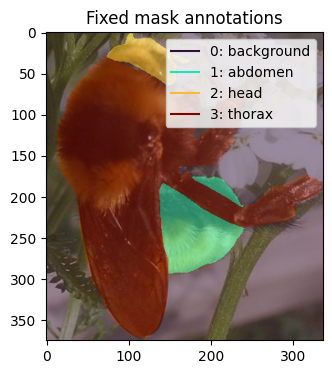

In [10]:
# Get sample image and mask
fig, axes = plt.subplots(1, 1, figsize=(24,4))
img, mask, image_path, mask_path = train_dataset[15]
plot_mask_annotation(image_path, mask_path, axes)

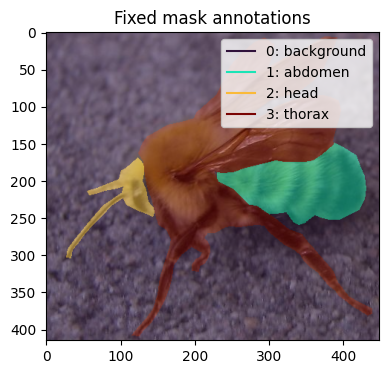

In [11]:
# Get sample image and mask
fig, axes = plt.subplots(1, 1, figsize=(24,4))
img, mask, image_path, mask_path = val_dataset[8]
plot_mask_annotation(image_path, mask_path, axes)

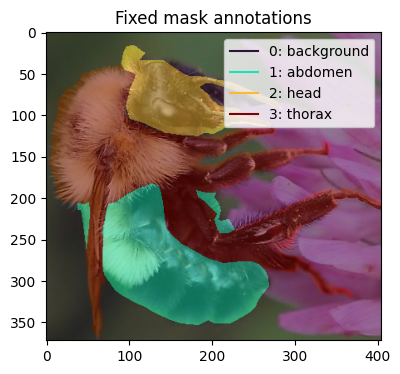

In [12]:
# Get sample image and mask
fig, axes = plt.subplots(1, 1, figsize=(24,4))
img, mask, image_path, mask_path = test_dataset[88]
plot_mask_annotation(image_path, mask_path, axes)

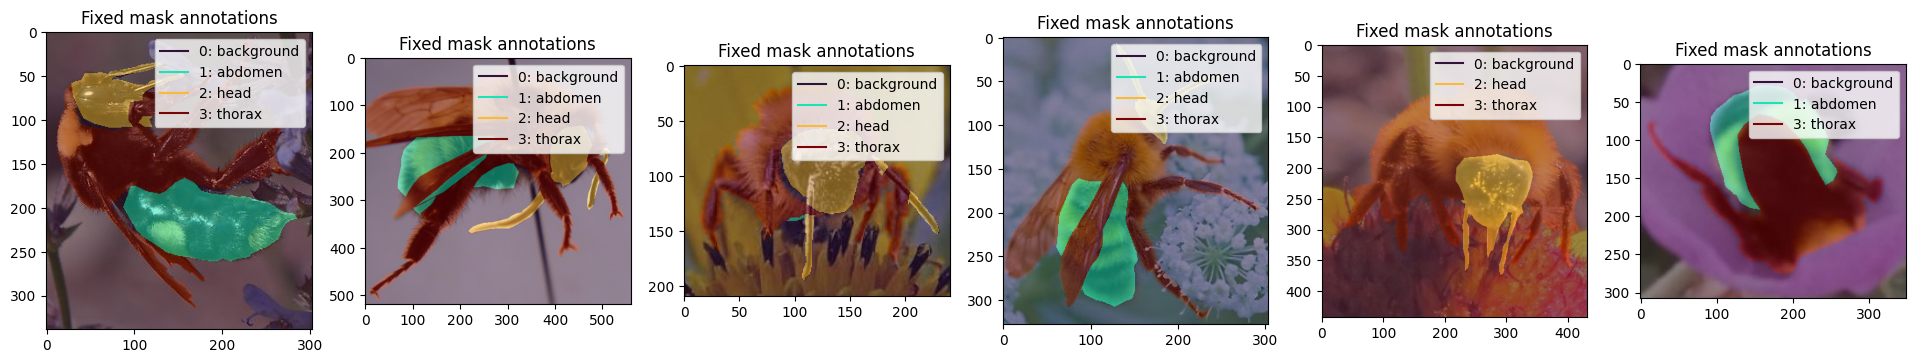

In [13]:
fig, axes = plt.subplots(1, 6, figsize=(24,4))
for i in range(6):
    img, mask, image_path, mask_path = test_dataset[i]
    plot_mask_annotation(image_path, mask_path, axes[i])